![CCAI 9012 course banner](../../../docs/figs/brand_identity/banner.png)

# Urban sentiment: what can 24 restaurant reviews tell us?

Imagine a city planner seeing a colourful review map. Are those colours public opinion or model labels for a small sample? We will send a fixed subset of 24 tracked Yelp comments to DeepSeek and keep each original comment beside its labels.

## What you will learn

- Trace a selected review from original text to polarity, emotion, and keywords.
- Compare model labels with star ratings without treating stars as ground truth.
- Read a sample map and word cloud without inferring citywide prevalence.
- Identify labels that need human checking.

![Review text and location stay linked to LLM labels before counts and map views.](../../../docs/figs/urban_sentiment_scorecard.svg)


## Step 1 — Select and label a fixed local sample

The tracked 60-row file supplies review text and locations. A fixed seed selects 24 rows; DeepSeek is called once per selected row by default. The output retains the original text so you can audit a label.


In [1]:
import matplotlib.pyplot as plt
from IPython.display import display
from ccai9012 import llm_utils, viz_utils
from ccai9012.paths import STARTER_KITS_DIR, ensure_output_dir

EXAMPLE_ROOT = STARTER_KITS_DIR / "2_llm_structure_output" / "urban_sentiment"
OUTPUT_DIR = ensure_output_dir(EXAMPLE_ROOT)
source_reviews = llm_utils.load_urban_review_sample(EXAMPLE_ROOT / "data/indy_reviews_sample.csv", n=24, random_state=42)
llm = llm_utils.initialize_llm(model="deepseek-chat", temperature=0)
reviews_df = llm_utils.analyze_reviews(
    source_reviews.rename(columns={"review_text": "text"}).to_dict("records"),
    llm, OUTPUT_DIR / "urban_sentiment_24.csv", max_reviews=24, sleep_time=0.1,
)
assert len(reviews_df) == 24, "Review labels incomplete; inspect model errors before plotting"
display(reviews_df[["review_text", "stars", "polarity", "sentiment", "keywords"]].head())


100%|██████████| 24/24 [00:36<00:00,  1.53s/it]


 Saved 24 analyzed reviews to /Users/kanxuanhe/Document/250421_AI_course/ccai9012/starter_kits/2_llm_structure_output/urban_sentiment/output/urban_sentiment_24.csv


,review_text,stars,polarity,sentiment,keywords
0,I stopped here because it was by the hotel I w...,5.0,positive,delighted,"friendly staff, buy one get one deal, hot wing..."
1,These place is so fun! The food is excellent!...,5.0,positive,delighted,"food, drinks, service, fun"
2,Note: This is not a fast food place. Expect to...,3.0,neutral,indifferent,"waiting time, sandwich, fries, price, airport"
3,"Food is very good, lovely interior......but......",3.0,negative,disappointed,"service, food, interior, attitude, appreciation"
4,"Went to try the Chocolate Chip Pancakes, and t...",4.0,positive,delighted,"Chocolate Chip Pancakes, pancake batter, textu..."


### Pause at the raw review

Read one `review_text` beside its `polarity` and `sentiment`. Would you assign the same labels? A star rating may refer to the visit overall while the text mixes praise and criticism.


,polarity,review_count,mean_stars,share
0,negative,3,2.000000,0.125000
1,neutral,2,3.000000,0.083333
2,positive,19,4.578947,0.791667


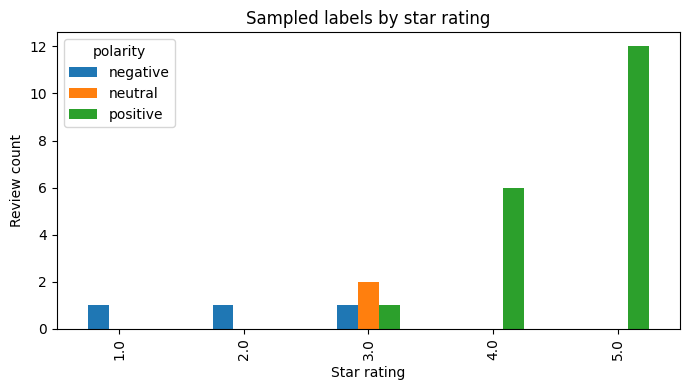

In [2]:
scorecard = (
    reviews_df.groupby("polarity", dropna=False)
    .agg(review_count=("review_text", "size"), mean_stars=("stars", "mean"))
    .reset_index()
)
scorecard["share"] = scorecard["review_count"] / scorecard["review_count"].sum()
scorecard.to_csv(OUTPUT_DIR / "city_scorecard_24.csv", index=False)
display(scorecard)

plt.figure(figsize=(7, 4))
reviews_df.groupby(["stars", "polarity"]).size().unstack(fill_value=0).plot.bar(ax=plt.gca())
plt.title("Sampled labels by star rating")
plt.xlabel("Star rating")
plt.ylabel("Review count")
plt.tight_layout()
plt.show()

## Step 2 — Map the selected comments

Each marker is a sampled business location, not a resident or a neighbourhood average. Before looking, predict whether nearby labels must agree; then inspect a marker and return to the text.


In [3]:
display(viz_utils.plot_review_heatmap(reviews_df.to_dict("records"), zoom_start=11))
display(viz_utils.plot_review_map(
    reviews_df,
    name_field="business_name",
    sentiment_field="polarity",
    map_center=[reviews_df["latitude"].mean(), reviews_df["longitude"].mean()],
    zoom=11,
))

## Step 3 — Read the keyword view

Bigger words recur in these 24 model-generated keyword lists. Compare a large word with the source comments before describing a theme.


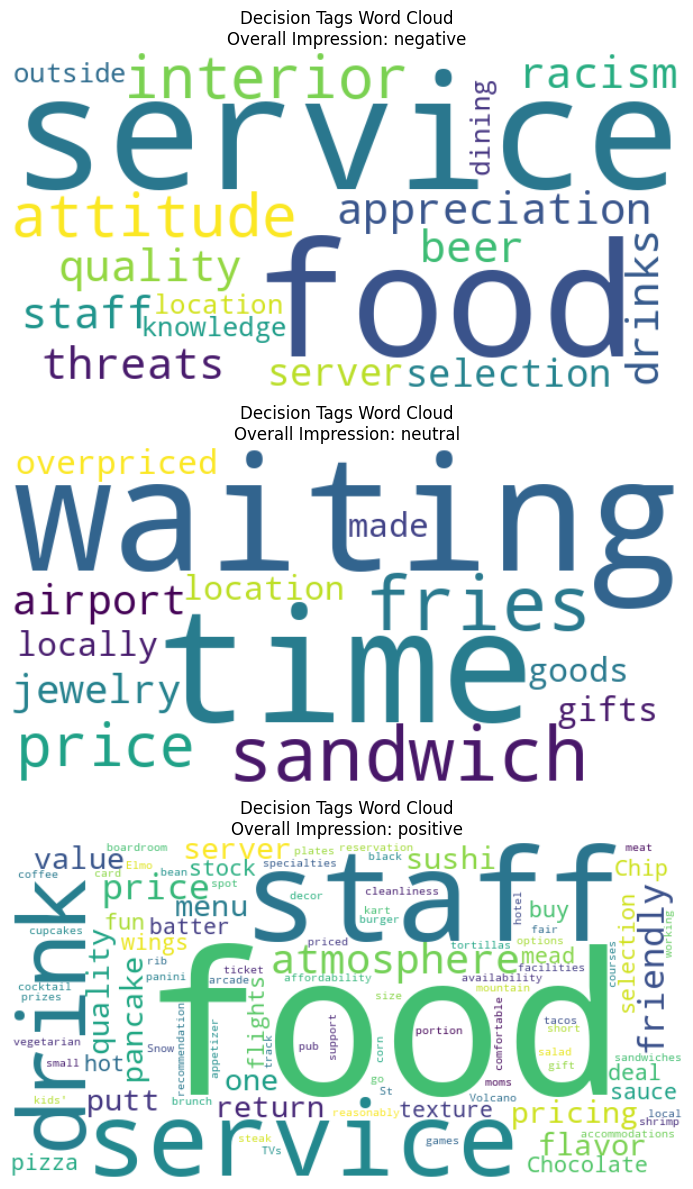

In [4]:
viz_utils.plot_wordclouds(reviews_df, target_col="polarity", tag_col="keywords")
plt.show()

## Reflect

Which labels would you send to a human reviewer? The sample is small, business reviews are selective, and model labels are uncertain. Saved CSVs can be reopened later; rerunning the notebook makes fresh DeepSeek requests.


In [5]:
display(reviews_df[["review_text", "stars", "polarity", "sentiment", "keywords"]].tail(3))


,review_text,stars,polarity,sentiment,keywords
21,AWESOME experience at this funky joint. Serv...,5.0,positive,delighted,"server, drinks, food, black bean burger, atmos..."
22,We love the Alexander and have stayed here 2 t...,4.0,positive,delighted,"hotel, comfortable, facilities, staff"
23,Silver in the City has some really nice jewelr...,3.0,neutral,disappointed,"jewelry, overpriced, gifts, location, locally ..."
